# Noisy observations: SL versus ASL
This experiment corrupts a fraction of expert decisions, trains SL and ASL models, compares predictive/regret metrics, and draws the ASL landscape.

In [1]:
%matplotlib inline
import invoptlab as io
from invoptlab.visualization import plot_loss_landscape_2d, plot_run_comparison


In [2]:
problem, dataset, theta_true = io.random_choice_experiment(
    observations=24, alternatives=6, seed=22,
    noise_model=io.RandomFeasibleNoise(probability=0.15),
)


In [3]:
runner = io.ExperimentRunner(io.ExperimentConfig(name='noise-comparison', geometry_samples=700))
sl = io.ProjectedSubgradientEstimator(
    loss=io.SuboptimalityLoss(), learning_rate=0.25, epochs=120, record_every=5, seed=22
)
asl = io.ProjectedSubgradientEstimator(
    loss=io.AugmentedSuboptimalityLoss(), learning_rate=0.25, epochs=120, record_every=5, seed=22
)
sl_result = runner.run(problem, dataset, sl)
asl_result = runner.run(problem, dataset, asl)
print('SL:', sl_result.theta, sl_result.metrics['mean_true_regret'])
print('ASL:', asl_result.theta, asl_result.metrics['mean_true_regret'])


SL: [ 0.00075318 -0.00843356] 2.198207202789742
ASL: [0.56742328 0.56715339] 0.0


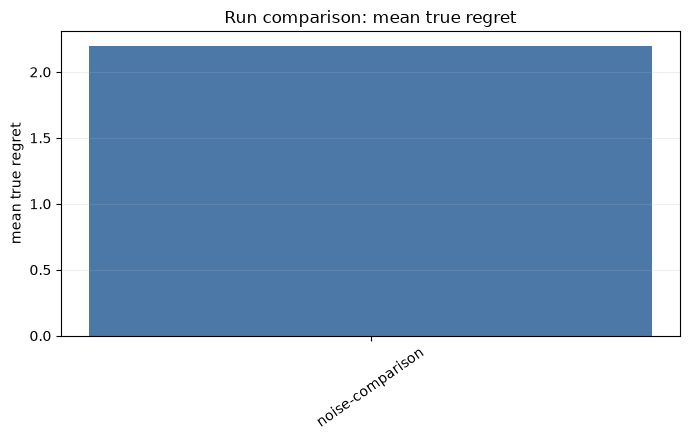

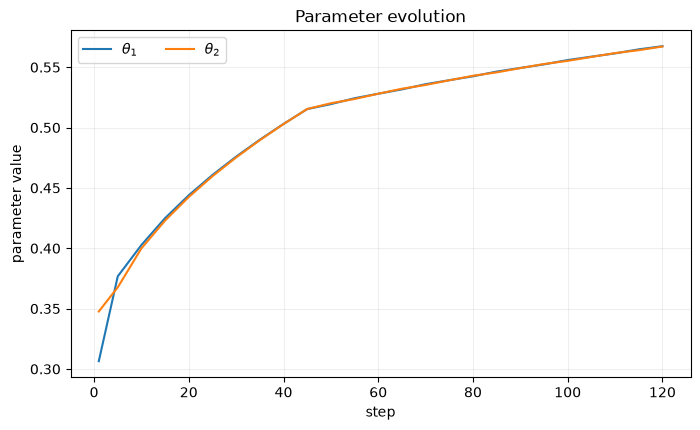

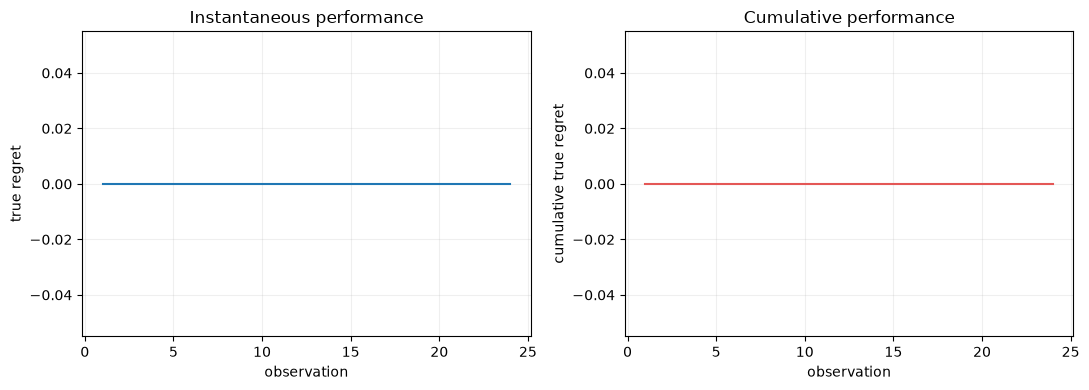

In [4]:
plot_run_comparison([sl_result, asl_result], 'mean_true_regret');
asl_result.plot_parameters();
asl_result.plot_regret();


In [5]:
landscape = plot_loss_landscape_2d(
    problem, dataset, io.AugmentedSuboptimalityLoss(), resolution=25, result=asl_result
)
landscape.show()
